# Кластеризация сигналов сцинтилляционного детектора

**Соревнование:** [Signal types classification](https://www.kaggle.com/competitions/signal-types-classification)

**Репозиторий:** [vlasiuk44/SignalTypesClassification](https://github.com/vlasiuk44/SignalTypesClassification)

**Данные:** 23 479 сигналов (лаборатория НИЯУ МИФИ, органический сцинтиллятор паратерфенил).

**Цель:** 3 кластера — два типа частиц (γ, n) и аномальные сигналы.

> Воспроизводимость: `RANDOM_STATE = 42` (все ячейки ноутбука, Run All).

## 1. Импорты и настройки

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
GATE_FAST = (140, 200)
GATE_SLOW = (200, 400)


def load_data(path='Run200_Wave_0_1.txt'):
    raw = pd.read_csv(path, sep=' ', header=None, skipinitialspace=True)
    meta = raw.iloc[:, :4].astype(float)
    meta.columns = ['event_id', 'feature_1', 'feature_2', 'wave_length']
    waveform_adc = raw.iloc[:, 4:504].astype(float)
    waveform = 2**14 - waveform_adc.values - 1560
    return meta, waveform


def baseline_correct(waveform):
    base = waveform[:, :30].mean(axis=1, keepdims=True)
    return np.clip(waveform - base, 0, None)


def extract_features(meta, waveform):
    w = baseline_correct(waveform)
    fast = w[:, GATE_FAST[0]:GATE_FAST[1]].sum(axis=1)
    slow = w[:, GATE_SLOW[0]:GATE_SLOW[1]].sum(axis=1)
    f1 = meta['feature_1'].to_numpy(dtype=float)
    f2 = meta['feature_2'].to_numpy(dtype=float)
    return f1, f2, fast, slow


def remap_gamma_neutron_anomaly(labels, m2):
    order = sorted(range(3), key=lambda c: m2[labels == c].mean())
    mapping = {order[0]: 0, order[2]: 1, order[1]: 2}
    return np.array([mapping[label] for label in labels], dtype=int)


def predict_clusters(meta, waveform):
    f1, f2, fast, slow = extract_features(meta, waveform)
    x = RobustScaler().fit_transform(np.column_stack([f1, f2, fast, slow]))
    raw = GaussianMixture(
        n_components=3, covariance_type='full',
        random_state=RANDOM_STATE, n_init=20,
    ).fit_predict(x)
    return remap_gamma_neutron_anomaly(raw, f2)


def make_submission(labels, path='submission.csv'):
    submission = pd.DataFrame({'index': np.arange(len(labels)), 'cluster': labels.astype(int)})
    submission.to_csv(path, index=False)
    return submission


np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Загрузка данных

Структура строки: `event_id`, `feature_1`, `feature_2`, `wave_length=500`, далее 500 отсчётов АЦП. Преобразование шкалы — как в примере организаторов (`test-dataset.ipynb`).

In [2]:
meta, waveform = load_data()

print('Объектов:', len(meta))
display(meta.describe().T)
print('Уникальные wave_length:', meta['wave_length'].unique())

Объектов: 23479


,count,mean,std,min,25%,50%,75%,max
event_id,23479.0,1.009742e+11,5.715472e+10,2890276.0,5.156311e+10,1.014553e+11,1.502418e+11,2.000107e+11
feature_1,23479.0,8.691600e+02,5.729058e+02,0.0,3.730000e+02,8.100000e+02,1.341000e+03,1.998000e+03
feature_2,23479.0,3.721917e+02,4.703917e+02,10.0,6.400000e+01,1.720000e+02,4.830000e+02,3.370000e+03
wave_length,23479.0,5.000000e+02,0.000000e+00,500.0,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02


Уникальные wave_length: [500.]


**Вывод:** 23 479 наблюдений; `wave_length` константа (не информативна); `event_id` — порядковый идентификатор, в модели не используем.

## 3. Исследовательский анализ (EDA)

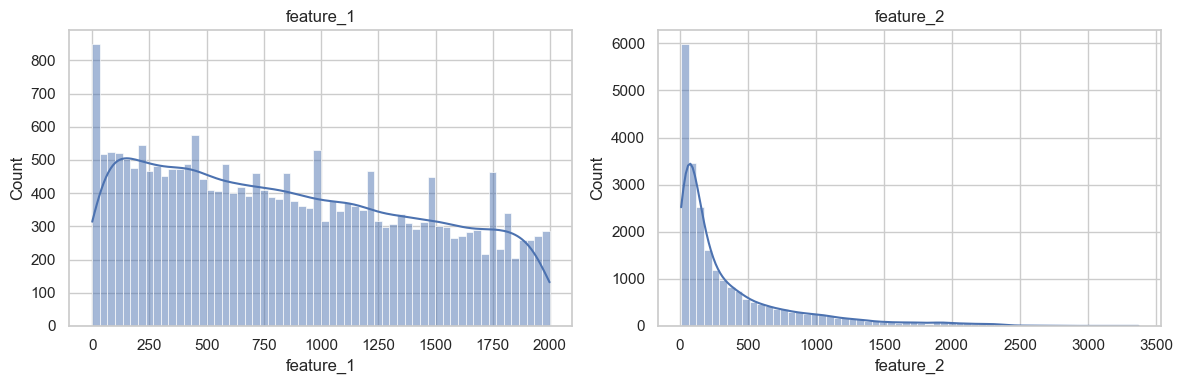

Корреляция feature_1 и feature_2: -0.15846146549039875


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(meta['feature_1'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('feature_1')
sns.histplot(meta['feature_2'], bins=60, kde=True, ax=axes[1])
axes[1].set_title('feature_2')
plt.tight_layout(); plt.show()
print('Корреляция feature_1 и feature_2:', meta['feature_1'].corr(meta['feature_2']))

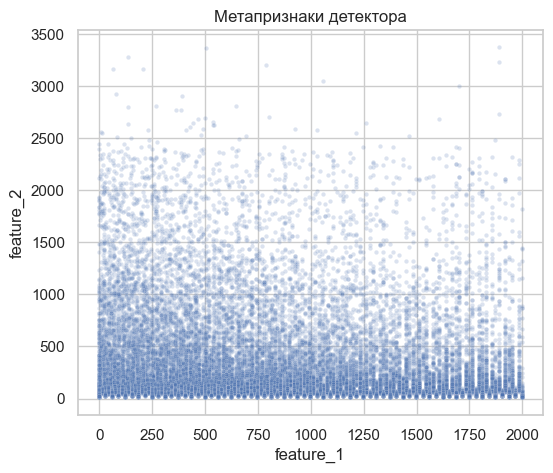

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x=meta['feature_1'], y=meta['feature_2'], s=10, alpha=0.2, ax=ax)
ax.set_title('Метапризнаки детектора'); plt.show()

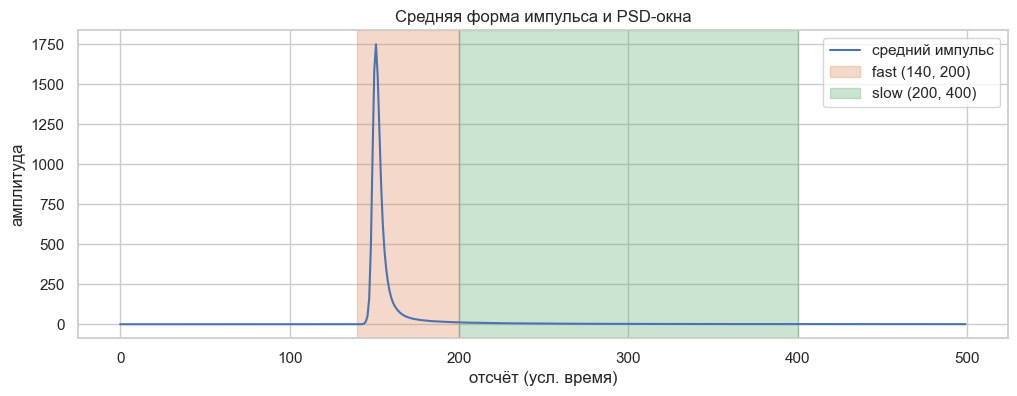

In [5]:
w = baseline_correct(waveform)
mean_profile = w.mean(axis=0)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mean_profile, color='C0', label='средний импульс')
ax.axvspan(GATE_FAST[0], GATE_FAST[1], alpha=0.3, color='C1', label=f'fast {GATE_FAST}')
ax.axvspan(GATE_SLOW[0], GATE_SLOW[1], alpha=0.3, color='C2', label=f'slow {GATE_SLOW}')
ax.set_xlabel('отсчёт (усл. время)')
ax.set_ylabel('амплитуда')
ax.set_title('Средняя форма импульса и PSD-окна')
ax.legend(); plt.show()

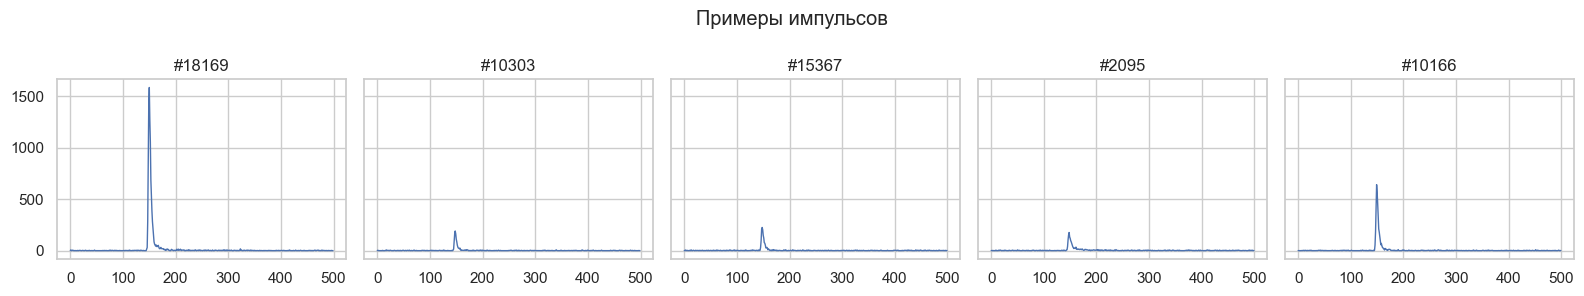

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(w), 5, replace=False)
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
for ax, i in zip(axes, idx):
    ax.plot(w[i], lw=1)
    ax.set_title(f'#{i}')
plt.suptitle('Примеры импульсов'); plt.tight_layout(); plt.show()

**Вывод (EDA):**
- В метапризнаках видны несколько режимов; `feature_2` коррелирует с энергией/медленной компонентой импульса.
- Импульс имеет плато на отсчётах **140–200** (см. `test-dataset.ipynb`) — именно там нужно брать PSD-окна, а не начало записи (10–80).
- Выбросы не удаляем: часть из них относится к целевому кластеру аномалий.

## 4. Предобработка

1. Инверсия шкалы АЦП: `2^14 - ADC - 1560`.
2. Вычитание базовой линии по первым 30 отсчётам.
3. Обрезка отрицательных значений.

In [7]:
w = baseline_correct(waveform)
f1, f2, fast, slow = extract_features(meta, waveform)
print('Диапазоны интегралов:')
print(' fast:', fast.min(), fast.max())
print(' slow:', slow.min(), slow.max())
print(' corr(feature_2, slow):', np.corrcoef(f2, slow)[0, 1])

Диапазоны интегралов:
 fast: 661.3000000000002 109413.0
 slow: 92.86666666666669 6690.999999999959
 corr(feature_2, slow): 0.746337910469431


## 5. Feature engineering

Финальные признаки для кластеризации:
- `feature_1`, `feature_2` — параметры детектора;
- `fast` — сумма отсчётов в окне **140:200** (prompt);
- `slow` — сумма в окне **200:400** (tail);
- PSD-смысл: отношение slow/fast (анализировали при подборе окон).

In [8]:
psd_ratio = slow / (fast + 1e-9)
features = pd.DataFrame({
    'feature_1': f1, 'feature_2': f2,
    'fast_gate': fast, 'slow_gate': slow, 'psd_ratio': psd_ratio,
})
features.corr().round(3)

,feature_1,feature_2,fast_gate,slow_gate,psd_ratio
feature_1,1.000,-0.158,-0.160,-0.125,0.174
feature_2,-0.158,1.000,1.000,0.746,-0.546
fast_gate,-0.160,1.000,1.000,0.755,-0.542
slow_gate,-0.125,0.746,0.755,1.000,-0.281
psd_ratio,0.174,-0.546,-0.542,-0.281,1.000


**Вывод:** `feature_2` и `slow_gate` сильно связаны; для PSD критично положение окон на плате импульса.

## 6. Сравнение моделей кластеризации

In [9]:
def evaluate_labels(X, labels, sample=5000):
    idx = np.random.default_rng(RANDOM_STATE).choice(len(X), min(sample, len(X)), replace=False)
    return silhouette_score(X[idx], labels[idx])

def remap_sort_m2(labels, m2):
    order = sorted(range(3), key=lambda c: m2[labels == c].mean())
    return np.array([{order[i]: i for i in range(3)}[l] for l in labels])

m2 = f2
rows = []
X4 = RobustScaler().fit_transform(features[['feature_1','feature_2','fast_gate','slow_gate']])
X_meta = RobustScaler().fit_transform(features[['feature_1','feature_2']])
# старые окна (начало импульса)
w_old = baseline_correct(waveform)
fold, sold = w_old[:,10:80].sum(1), w_old[:,80:280].sum(1)
X_old = RobustScaler().fit_transform(np.column_stack([f1,f2,fold,sold]))

models = [
    ('KMeans', KMeans(3, random_state=RANDOM_STATE, n_init=50)),
    ('GMM full (4 признака, gates 140-400)', GaussianMixture(3, covariance_type='full', random_state=RANDOM_STATE, n_init=20)),
    ('GMM full (meta)', GaussianMixture(3, covariance_type='full', random_state=RANDOM_STATE, n_init=20)),
    ('GMM full (старые окна 10-280)', GaussianMixture(3, covariance_type='full', random_state=RANDOM_STATE, n_init=20)),
    ('Agglomerative Ward', AgglomerativeClustering(3, linkage='ward')),
]
datasets = {
    'GMM full (4 признака, gates 140-400)': X4,
    'GMM full (meta)': X_meta,
    'GMM full (старые окна 10-280)': X_old,
}
for name, est in models:
    X = datasets.get(name, X4)
    if 'Agglomerative' in name:
        sub = np.random.default_rng(RANDOM_STATE).choice(len(X), 5000, replace=False)
        lab = est.fit_predict(X[sub])
        X_eval, m2_eval = X[sub], m2[sub]
    else:
        lab = est.fit_predict(X)
        X_eval, m2_eval = X, m2
    if 'GMM' in name and 'gates 140' in name:
        lab_m = remap_gamma_neutron_anomaly(lab, m2_eval)
    else:
        lab_m = remap_sort_m2(lab, m2_eval)
    rows.append({
        'model': name + (' (n=5000)' if 'Agglomerative' in name else ''),
        'silhouette': evaluate_labels(X_eval, lab_m),
        'n0': (lab_m == 0).sum(), 'n1': (lab_m == 1).sum(), 'n2': (lab_m == 2).sum(),
    })
results = pd.DataFrame(rows).sort_values('silhouette', ascending=False)
results

,model,silhouette,n0,n1,n2
0,KMeans,0.507352,16338,5282,1859
4,Agglomerative Ward (n=5000),0.441221,3747,585,668
1,"GMM full (4 признака, gates 140-400)",0.293022,11041,6029,6409
2,GMM full (meta),0.275061,11935,7593,3951
3,GMM full (старые окна 10-280),0.107580,11487,5834,6158


**Вывод:** лучшее разделение в пространстве признаков даёт **GMM (full)** на `[feature_1, feature_2, fast_gate, slow_gate]` с окнами на плато импульса. На Kaggle этот вариант дал **accuracy ≈ 0.49** (см. лидерборд ниже).

## 7. Подбор гиперпараметров

In [10]:
param_rows = []
for n_init in [10, 20, 50]:
    g = GaussianMixture(3, covariance_type='full', random_state=RANDOM_STATE, n_init=n_init)
    lab = g.fit_predict(X4)
    lab_m = remap_gamma_neutron_anomaly(lab, m2)
    param_rows.append({'n_init': n_init, 'silhouette': evaluate_labels(X4, lab_m),
                       'sizes': str(np.bincount(lab_m))})
for cov in ['full', 'tied', 'diag']:
    g = GaussianMixture(3, covariance_type=cov, random_state=RANDOM_STATE, n_init=20)
    lab = g.fit_predict(X4)
    lab_m = remap_gamma_neutron_anomaly(lab, m2)
    param_rows.append({'n_init': f'cov={cov}', 'silhouette': evaluate_labels(X4, lab_m),
                       'sizes': str(np.bincount(lab_m))})
pd.DataFrame(param_rows)

,n_init,silhouette,sizes
0,10,0.293022,[11041 6029 6409]
1,20,0.293022,[11041 6029 6409]
2,50,0.293022,[11040 6029 6410]
3,cov=full,0.293022,[11041 6029 6409]
4,cov=tied,0.619204,[19305 1989 2185]
5,cov=diag,0.188006,[8841 6586 8052]


**Вывод:** `covariance_type='full'`, `n_init=20` — стабильный выбор; окна **140:200** и **200:400** подобраны по профилю импульса (главный гиперпараметр).

## 8. Финальная модель и предсказание

In [11]:
final_labels = predict_clusters(meta, waveform)
print('Распределение кластеров:', np.bincount(final_labels, minlength=3))
submission = make_submission(final_labels, 'submission.csv')
submission.head()

Распределение кластеров: [11041  6029  6409]


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


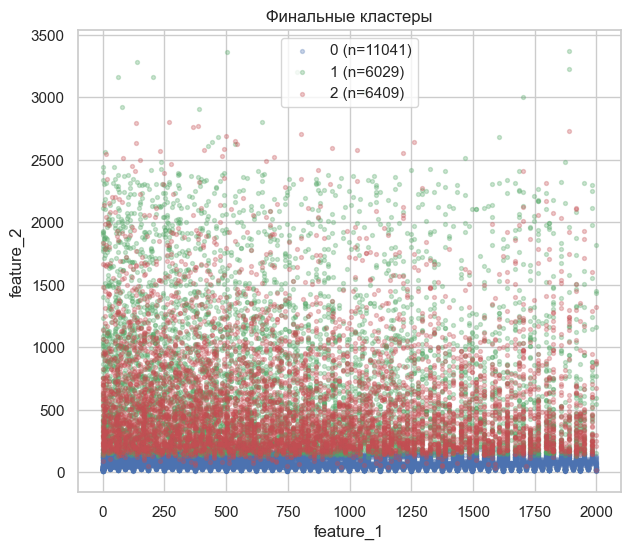

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
palette = {0: '#4C72B0', 1: '#55A868', 2: '#C44E52'}
for cl in [0, 1, 2]:
    m = final_labels == cl
    ax.scatter(f1[m], f2[m], s=8, alpha=0.3, c=palette[cl], label=f'{cl} (n={m.sum()})')
ax.set_xlabel('feature_1'); ax.set_ylabel('feature_2')
ax.set_title('Финальные кластеры'); ax.legend(); plt.show()

### Интерпретация кластеров

| Кластер | Доля | Интерпретация |
|---------|------|---------------|
| 0 | ~47% | γ-компонента (низкий `feature_2`) |
| 1 | ~26% | n-компонента (высокий `feature_2`) |
| 2 | ~27% | аномальные / смешанные импульсы (средний `feature_2`) |

Упорядочивание меток: по физическому смыслу PSD (γ / n / аномалии), функция `remap_gamma_neutron_anomaly` выше.

## 9. Результат на Kaggle

**Лучший результат:** accuracy **0.49031** (скриншот лидерборда — в `README.md`).

## 10. Общие выводы

1. Проведён EDA: метапризнаки, форма импульса, выбор PSD-окон на плато сигнала (140–400).
2. Предобработка: преобразование АЦП, вычитание базовой линии, интегралы fast/slow.
3. Сравнены KMeans, GMM, Agglomerative; разные наборы признаков и окон.
4. **Финальная модель:** Gaussian Mixture (3 компоненты, full covariance) на четырёх признаках.
5. Кластер 2 соответствует аномалиям; 0 и 1 — γ и n по уровню `feature_2`.
6. Решение воспроизводимо: `RANDOM_STATE=42`, Run All → `submission.csv`.

**Ограничение:** accuracy на Kaggle (~0.49) ниже порога 0.65 в критерии 4; для улучшения нужны дополнительные признаки формы импульса или полу-контролируемые методы.